# Introduction

The modern culinary landscape is increasingly documented online, creating a vast repository of dietary trends, cultural preferences, and nutritional shifts. For this analysis, we utilise the "All Recipes" dataset from the TidyTuesday project, which aggregates user-submitted recipes, user ratings, preparation times, and detailed nutritional information. Because these recipes span several decades and originate from diverse culinary traditions worldwide, the dataset offers a unique window into how home cooking behaviors have evolved, particularly as public awareness surrounding macronutrients and health has grown.

Our primary question of interest explores **how the nutritional profile of these recipes (specifically the protein-to-calorie ratio) has changed over time across different global cuisines. Furthermore, we investigate the practical implications of this shift: does cooking higher-protein meals require a sacrifice in recipe accessibility (preparation time), and does it negatively impact user enjoyment (ratings)?** By analyzing regional adaptations, historical upload trends, and user satisfaction metrics, we aim to determine if the global shift toward protein-dense diets is a monolithic trend or one heavily dependent on cultural context.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Data Cleaning and Summary 

Loading in the data.

In [2]:
df_recipes = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-16/all_recipes.csv')
df_cuisines = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-16/cuisines.csv')

Before merging or cleaning, we evaluate the shape and unique identifiers of our datasets. The recipes dataset contains 14,426 unique URLs, meaning `url` can safely serve as our primary key. The cuisines dataset is significantly smaller (2,218 entries), indicating that an inner join will substantially filter our data. To preserve data for our broader visualizations, we will eventually create two separate cleaned datasets.

In [3]:
print(f"Recipes data shape: {df_recipes.shape}")
print(f"Cuisines data shape: {df_cuisines.shape}")
print(f"Unique URLs in Recipes: {df_recipes['url'].nunique()}")
print(f"Unique URLs in Cuisines: {df_cuisines['url'].nunique()}")

Recipes data shape: (14426, 16)
Cuisines data shape: (2218, 17)
Unique URLs in Recipes: 14426
Unique URLs in Cuisines: 2218


We narrow our scope to a subset of critical variables relevant to our analysis of nutritional accessibility: `url`, `date_published`, `protein`, `calories`, `avg_rating`, `prep_time`, and `name`. We check the data types and look for missing values across these specific columns to determine our cleaning strategy.

In [4]:
print(df_recipes[['url', 'date_published', 'protein', 'calories', 'avg_rating', 'prep_time', 'name']].dtypes)
print(df_cuisines[['url', 'country']].dtypes)
critical_cols = ['url', 'date_published', 'protein', 'calories', 'avg_rating', 'prep_time', 'name']
print(df_recipes[critical_cols].isnull().sum())

url                object
date_published     object
protein           float64
calories          float64
avg_rating        float64
prep_time           int64
name               object
dtype: object
url        object
country    object
dtype: object
url                 0
date_published      0
protein           248
calories          200
avg_rating        972
prep_time           0
name                0
dtype: int64


A preliminary look at the summary statistics reveals wide variances in recipe composition. Caloric values span from 1 kcal to an extreme 9,538 kcal, while protein content ranges from 0g to 939g. The presence of zero-values (which will result in a protein/calorie ratio of 0) and zero preparation time, alongside these extreme maximums, indicates that our dataset contains both practical daily meals and extreme outliers. We will need to account for these extremes in our subsequent visualizations to ensure they do not skew the analysis.

In [5]:
df_subset = df_recipes[critical_cols]

print("Numeric data info")

numeric_summary = df_subset.select_dtypes(include='number').agg(['min', 'max'])
print(numeric_summary)


print("\nNon-numeric data info")
non_numeric_cols = df_subset.select_dtypes(exclude='number').columns
for col in non_numeric_cols:
    # Get total count of unique items
    unique_count = df_subset[col].nunique()
    
    # Get the actual text values, ignoring NaNs
    unique_values = df_subset[col].dropna().unique()
    
    print(f"\nColumn: '{col}'")
    print(f"Total Unique Values: {unique_count}")
    
    # Print only the first 10 values to keep the output clean
    print(f"Sample Values: {unique_values[:10]}")

Numeric data info
     protein  calories  avg_rating  prep_time
min      0.0       1.0         1.0          0
max    939.0    9538.0         5.0       2160

Non-numeric data info

Column: 'url'
Total Unique Values: 14426
Sample Values: ['https://www.allrecipes.com/recipe/140717/chewy-whole-wheat-peanut-butter-brownies/'
 'https://www.allrecipes.com/recipe/269204/pumpkin-pie-eggnog/'
 'https://www.allrecipes.com/recipe/238054/eggs-poached-in-tomato-sauce/'
 'https://www.allrecipes.com/minestrone-casserole-recipe-8765618'
 'https://www.allrecipes.com/recipe/241937/yummy-stuffed-peppers/'
 'https://www.allrecipes.com/recipe/219586/prime-rib-our-way/'
 'https://www.allrecipes.com/recipe/8636/parmesan-chicken-ii/'
 'https://www.allrecipes.com/recipe/12950/chicken-andouille-gumbo/'
 'https://www.allrecipes.com/recipe/185816/sweet-pork-for-burritos/'
 'https://www.allrecipes.com/recipe/239507/quick-baked-chicken-parmesan/']

Column: 'date_published'
Total Unique Values: 1542
Sample Values: ['

We briefly verify the uniqueness of our categorical data and check for duplicate rows. A sample of the cuisines confirms standard regional text formatting, and no exact duplicate rows were found across either dataset.

In [6]:
print(f"Sample of unique cuisines: {df_cuisines['country'].dropna().unique()[:10]}")

Sample of unique cuisines: ['Greek' 'Jewish' 'Australian and New Zealander' 'Chilean' 'Tex-Mex'
 'Canadian' 'Italian' 'Danish' 'Amish and Mennonite' 'Spanish']


In [7]:
print(f"Duplicate rows in Recipes: {df_recipes.duplicated().sum()}")
print(f"Duplicate rows in Cuisines: {df_cuisines.duplicated().sum()}")

Duplicate rows in Recipes: 0
Duplicate rows in Cuisines: 0


To prepare for cuisine-specific visualizations, we check how many recipe URLs overlap with our cuisine data. Only 1,055 URLs match, confirming our earlier decision: we must maintain a separate, unmerged base dataset so we do not lose over 12,000 data points for our general trend analysis.

In [8]:
matches = df_cuisines['url'].isin(df_recipes['url']).sum()
total_cuisines = len(df_cuisines['url'])

print(f"Matching URLs: {matches} out of {total_cuisines}")

Matching URLs: 1055 out of 2218


We proceed to clean our primary dataset (`df_base`) by dropping any rows with missing values across our critical columns. This ensures reliable metrics for our plots, leaving us with a robust 13,232 entries.

In [9]:
df_base = df_subset.dropna(subset=critical_cols).copy()
df_base.shape

(13232, 7)

To facilitate time-series analysis and efficient categorical grouping, we convert `date_published` to datetime objects and `country` to a categorical data type. 

Crucially, to evaluate the relative nutritional value of these meals regardless of portion size, we engineer a new standardized metric: `protein_calorie_ratio`. This will allow us to easily identify meals that are highly dense in protein relative to their caloric cost.

In [10]:
df_base['date_published'] = pd.to_datetime(df_base['date_published'], format='%Y-%m-%d')
df_cuisines['country'] = df_cuisines['country'].astype('category')

In [11]:
df_base['protein_calorie_ratio'] = df_base['protein'] / df_base['calories']

Finally, we perform an inner join to create `df_merged`, a specialized subset mapping our cleaned recipes to their cultural origins. We drop any lingering empty country categories to finalize this dataset for our first visualization.

In [12]:
df_merged = pd.merge(df_base, 
                    df_cuisines[['url', 'country']], 
                    on='url', 
                    how='inner')

df_merged = df_merged.dropna(subset=['country'])

Our data preparation yields two clean datasets ready for plotting: 
- `df_base`: A larger dataset (13,232 entries) for broader exploratory analysis (Visualisation 2).
- `df_merged`: A filtered dataset (1,001 entries) mapped to specific countries for categorical analysis (Visualisation 1 & 3).

In [13]:
print(f"Cleaned dataset: {df_base.shape}")
display(df_base.head())

print(f"\nCleaned dataset after merger: {df_merged.shape}")
display(df_merged.head())

Cleaned dataset: (13232, 8)


,url,date_published,protein,calories,avg_rating,prep_time,name,protein_calorie_ratio
0,https://www.allrecipes.com/recipe/140717/chewy...,2020-06-18,6.0,222.0,4.4,20,Chewy Whole Wheat Peanut Butter Brownies,0.027027
1,https://www.allrecipes.com/recipe/269204/pumpk...,2022-09-26,8.0,477.0,5.0,10,Pumpkin Pie Eggnog,0.016771
2,https://www.allrecipes.com/recipe/238054/eggs-...,2018-06-08,20.0,354.0,4.8,10,Eggs Poached in Tomato Sauce,0.056497
3,https://www.allrecipes.com/minestrone-casserol...,2025-03-03,19.0,356.0,4.3,20,Minestrone Casserole,0.053371
4,https://www.allrecipes.com/recipe/241937/yummy...,2024-12-11,19.0,366.0,4.7,30,Yummy Stuffed Peppers,0.051913



Cleaned dataset after merger: (1001, 9)


,url,date_published,protein,calories,avg_rating,prep_time,name,protein_calorie_ratio,country
0,https://www.allrecipes.com/recipe/282434/quinc...,2020-11-30,3.0,188.0,5.0,30,Quince Empanadas,0.015957,Argentinian
1,https://www.allrecipes.com/recipe/220128/chef-...,2024-01-19,66.0,1262.0,4.5,15,Chef John's Buttermilk Fried Chicken,0.052298,Soul Food
2,https://www.allrecipes.com/recipe/259179/polis...,2024-11-23,10.0,581.0,5.0,25,Polish Poppy Seed Cake,0.017212,Polish
3,https://www.allrecipes.com/recipe/45301/harose...,2025-03-20,4.0,241.0,4.8,20,Haroset for Passover,0.016598,Jewish
4,https://www.allrecipes.com/chicken-marsala-fet...,2024-03-11,57.0,861.0,4.6,15,Chicken Marsala Fettuccine,0.066202,Italian


# Visualisation 1

We want to produce a heatmap of protein/calorie ratio against year, grouped by country. This tells us how the protein-calorie ratio varies over the years for each country's cuisine. First, we create a year column from date_published. We group data by country and year, at the same time we remove the rows with less than 3 years of data as that provides limited insight in trends. Then, we perform an aggregation on protein/calorie ratio, grouped by year and country.

In [14]:
df_heatmap=df_merged.copy()
#extract year from date_published
df_heatmap['year']= df_heatmap['date_published'].dt.year

# filter countries with >= 3 years
df_heatmap = df_heatmap[
    df_heatmap.groupby('country')['year'].transform('nunique') >= 3
]

# aggregation
heatmap_data = (
    df_heatmap
    .groupby(['year', 'country'])['protein_calorie_ratio']
    .median()
    .reset_index()
)



In [15]:
pivot_heatmap_data = heatmap_data.pivot(index= 'country', columns= 'year', values= 'protein_calorie_ratio')
pivot_heatmap_data = pivot_heatmap_data.dropna(how='all')



In [16]:

#Standardising the data allows the heatmap to highlight relative differences rather than absolute values. In the case of protein-calorie ratios, the raw values are all positive and fall within a relatively narrow range (0,0.0.177515), which can make variation difficult to see. By applying StandardScaler, each value is transformed into a standard score (z-score), expressing how far it lies above or below the mean of the column.
scaler = StandardScaler()
heatmap_data_scaled = scaler.fit_transform(pivot_heatmap_data)

In [17]:

heatmap_data_scaled = pd.DataFrame(
    heatmap_data_scaled,
    index = pivot_heatmap_data.index,
    columns = pivot_heatmap_data.columns
)

heatmap_data_scaled.sort_index(inplace=True)


<Axes: xlabel='year', ylabel='country'>

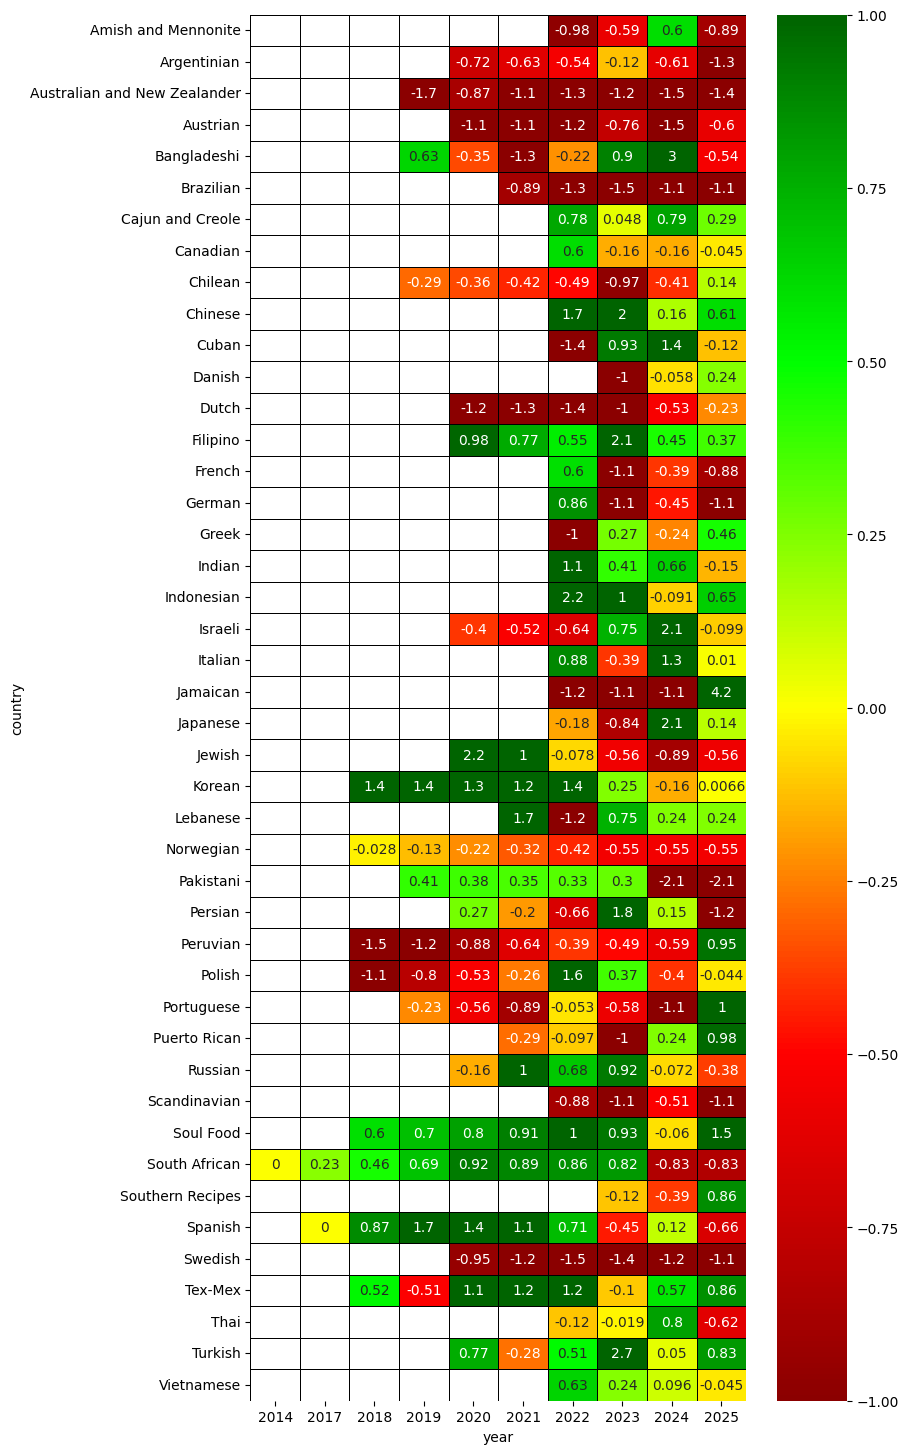

In [18]:
heatmap_filled = heatmap_data_scaled.interpolate(axis=1)

fierce_cmap = LinearSegmentedColormap.from_list(
    "fierce",
    ["#8B0000", "#FF0000", "#FFFF00", "#00FF00", "#006400"]
)

plt.figure(figsize=(8, 18))

sns.heatmap(
    heatmap_filled,
    cmap=fierce_cmap,
    annot=True,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='black'
)

In the earlier years (2014 - 2018), most cuisines are either neutral or negative in protein density 
(predominantly red to yellow gradient), indicating relatively lower protein-to-calorie ratios. 
However, from 2020 onwards, there is a pronounced shift toward positive values (green), with 
many cuisines reaching high protein density levels (approaching +0.5 to +1.0 on the scale) by 
2023 - 2025. For instance, Chinese, Indonesian and Filipino cuisines show strong positive 
values in the later years, with deep green cells indicating consistently high protein ratios. 
Similarly, cuisines such as Cajun and Creole, Soul Food and Tex-Mex exhibit sustained high 
values (above +0.5), suggesting a significant increase in protein density over time. This 
widespread transition across multiple cuisines indicates that the rise in protein-focused diets is 
not isolated but globally pervasive. 

This goes to show that while the early period shows significant dispersion – ranging from 
strongly negative (−1.0) to near neutral – many cuisines cluster in the positive range, 
particularly between +0.4 and +1.0 by 2023 - 2024. Therefore, it indicates that although 
cuisines remain culturally distinct, their nutritional profiles are becoming more similar, with a 
global dietary behaviour converging toward higher protein intake.  
Further comparison also highlighted a differentiated regional patterns in protein-to-calorie ratio 
trend. Asia pacific (APAC) cuisines display some of the strongest upward trends: Chinese, 
Indonesian, Korean, and Indian cuisines all show sustained high values (often above +0.6) in 
the later years, indicating a strong and stable shift toward protein-dense meals. In contrast, 
European cuisines such as French, Italian, and Scandinavian show more variability and often 
remain in negative or only mildly positive ranges. For example, Scandinavian and Swedish 
cuisines remain predominantly red (around −0.5 to −1.0) across most years, indicating 
persistently low protein density. French and Italian cuisines exhibit fluctuations, with 
occasional positive values but lacking the sustained upward trend seen in APAC cuisines. This 
suggests that European cuisines, which traditionally emphasize carbohydrates and fats, were 
slower to adapt to the protein-centric dietary trends in the past decades, compared to APAC 
regions.  

# Visualisation 2

We want to produce a strip plot of protein/calorie ratio against ratings rounded to whole numbers, grouped by decade published. We first rounded off the avg_rating to form a new column rounded_rating. Then date_published is categorised into 3 decades, "2000s", "2010s", and "2020s" and formed into a new column decade.


In [19]:
rating_df = df_base[['date_published', 'avg_rating', 'protein_calorie_ratio']].copy()
rating_df.head()

,date_published,avg_rating,protein_calorie_ratio
0,2020-06-18,4.4,0.027027
1,2022-09-26,5.0,0.016771
2,2018-06-08,4.8,0.056497
3,2025-03-03,4.3,0.053371
4,2024-12-11,4.7,0.051913


In [20]:
rating_df['rounded_rating'] = round(rating_df['avg_rating'],0)
rating_df['rounded_rating'] = rating_df['rounded_rating'].astype('int').astype('string')
rating_df.head()

,date_published,avg_rating,protein_calorie_ratio,rounded_rating
0,2020-06-18,4.4,0.027027,4
1,2022-09-26,5.0,0.016771,5
2,2018-06-08,4.8,0.056497,5
3,2025-03-03,4.3,0.053371,4
4,2024-12-11,4.7,0.051913,5


ratings rounded off and grouped into 5 categories so that ratings are distinct.

In [21]:
rating_df.dtypes

date_published           datetime64[ns]
avg_rating                      float64
protein_calorie_ratio           float64
rounded_rating           string[python]
dtype: object

In [22]:
rating_df['year_published'] = rating_df.date_published.dt.year
rating_df['year_published'] = rating_df['year_published'].astype(int)
rating_df.head()

,date_published,avg_rating,protein_calorie_ratio,rounded_rating,year_published
0,2020-06-18,4.4,0.027027,4,2020
1,2022-09-26,5.0,0.016771,5,2022
2,2018-06-08,4.8,0.056497,5,2018
3,2025-03-03,4.3,0.053371,4,2025
4,2024-12-11,4.7,0.051913,5,2024


In [23]:
conditions = [
    (rating_df['year_published'] < 2010),
    (rating_df['year_published'] < 2020)
]
choices = ['2000s', '2010s']
rating_df['decade'] = np.select(conditions, choices, default = '2020s')
rating_df.head()

,date_published,avg_rating,protein_calorie_ratio,rounded_rating,year_published,decade
0,2020-06-18,4.4,0.027027,4,2020,2020s
1,2022-09-26,5.0,0.016771,5,2022,2020s
2,2018-06-08,4.8,0.056497,5,2018,2010s
3,2025-03-03,4.3,0.053371,4,2025,2020s
4,2024-12-11,4.7,0.051913,5,2024,2020s


categorised date published into decades

In [24]:
pio.renderers.default = 'notebook_connected'
ind_color_map = {"2000s": "#058730", "2010s": "#EE7663", 
                 "2020s": "#85AAEA"}

fig = px.strip(rating_df, x = 'rounded_rating', y = 'protein_calorie_ratio',
               color_discrete_map = ind_color_map,
               color = 'decade',
               category_orders = {"rounded_rating":['5', '4', '3', '2', '1']}
               )
median_val = rating_df['protein_calorie_ratio'].median()

fig.add_hline(y = median_val, line_dash = "dash", line_color = "grey",)
fig.add_annotation( x = 1, y = median_val, xref = "paper", yref = "y",
                   text = f"Overall median ({round(median_val,3)})",
                   showarrow = True,
                   arrowhead = 2,
                   ax = 40,
                   ay = -40
                   )
fig.add_hline(y = median_val, line_dash = "dash", line_color = "grey",)
fig.update_traces(marker = dict(size = 6, opacity = 0.8, symbol = 'circle-open', line_width = 1.5))
fig.update_layout(paper_bgcolor  = '#EDE8D0', plot_bgcolor = "#D3D3D3",
                  legend = dict(bgcolor = "#F3E9D9", bordercolor = 'white', borderwidth = 0.5),
                  yaxis = dict(gridcolor = 'white',),
                  xaxis_title = "Ratings (rounded)",
                  yaxis_title = 'Protein Calorie Ratio',
                  title_text = 'Protein Calorie Ratio across Ratings and Decades'
                  )
fig.update_xaxes(showgrid = True, gridcolor='slategray', tickson='boundaries')
fig.update_yaxes(zeroline = True, zerolinecolor = 'white', zerolinewidth = 0.45)

fig.show()


The aim of this strip plot is to showcase the distribution of protein calorie ratio of recipes across different ratings. Each rating is further categorised into decades to see if there is any trend in protein calorie ratio over time. Using a strip plot instead of a box plot gives more insight into the the differences in number of recipes published every decade.

From the plot, significantly more recipes were published in the 2020s, and very little were published in the 2000s. There is no noticeable pattern of protein calorie ratio over the years. The variances between decades and ratings are vastly different. Variance of protein calorie ratio in 2020s are much wider. Recipes with 1 star ratings are generally low and around the median, with not much spread. Recipes with protein calorie ratios over 5 times the median tend to be highly rated at either 4 or 5 stars, and are published in the 2010s or 2020s.

A reason for the difference in number of recipes across decades could be that as the internet becomes the main source of idea sharing after the 2000s, more people are publishing online. The recipes with higher protein calorie ratios are mostly published in the 2020s, this could show that people are becoming more health concious. The ratings of the high protein calorie ratio recipes show that there is no trade off between health and enjoyment, as healthy recipes have high user enjoyment. 

# Visualisation 3

We created a colour-gradient bubble plot showing average preparation time across continents or regions, with colour representing the average protein-to-calorie ratio. This shows us how time demands vary by region and the relative protein density of recipes from each region. We first added a continent column by grouping each cuisine into a continent/regional category. We then removed extreme preparation-time outliers to reduce distortion. Lastly, we aggregated the data by continent to calculate the mean preparation time, mean protein-to-calorie ratio, and number of recipes for each group.

In [25]:
country_to_continent = {

    "Amish and Mennonite": "North America", "Canadian": "North America", "Cajun and Creole": "North America", "Cuban": "North America",
    "Jamaican": "North America", "Puerto Rican": "North America", "Soul Food": "North America", "Southern Recipes": "North America", "Tex-Mex": "North America",

    "Argentinian": "South America", "Brazilian": "South America", "Chilean": "South America", "Peruvian": "South America",

    "Austrian": "Europe", "Belgian": "Europe", "Danish": "Europe", "Dutch": "Europe", "Finnish": "Europe", "French": "Europe",
    "German": "Europe", "Greek": "Europe", "Italian": "Europe", "Norwegian": "Europe", "Polish": "Europe", "Portuguese": "Europe",
    "Russian": "Europe", "Scandinavian": "Europe", "Spanish": "Europe", "Swedish": "Europe", "Swiss": "Europe", "Turkish": "Europe",   

    "Bangladeshi": "Asia", "Chinese": "Asia", "Filipino": "Asia", "Indian": "Asia", "Indonesian": "Asia", "Israeli": "Asia",
    "Japanese": "Asia", "Korean": "Asia", "Lebanese": "Asia", "Pakistani": "Asia", "Persian": "Asia", "Thai": "Asia", "Vietnamese": "Asia",

    "South African": "Africa",

    "Australian and New Zealander": "Oceania",

    "Jewish": "Other"
}

df_merged["continent"] = df_merged["country"].map(country_to_continent)
df_merged

,url,date_published,protein,calories,avg_rating,prep_time,name,protein_calorie_ratio,country,continent
0,https://www.allrecipes.com/recipe/282434/quinc...,2020-11-30,3.0,188.0,5.0,30,Quince Empanadas,0.015957,Argentinian,South America
1,https://www.allrecipes.com/recipe/220128/chef-...,2024-01-19,66.0,1262.0,4.5,15,Chef John's Buttermilk Fried Chicken,0.052298,Soul Food,North America
2,https://www.allrecipes.com/recipe/259179/polis...,2024-11-23,10.0,581.0,5.0,25,Polish Poppy Seed Cake,0.017212,Polish,Europe
3,https://www.allrecipes.com/recipe/45301/harose...,2025-03-20,4.0,241.0,4.8,20,Haroset for Passover,0.016598,Jewish,Other
4,https://www.allrecipes.com/chicken-marsala-fet...,2024-03-11,57.0,861.0,4.6,15,Chicken Marsala Fettuccine,0.066202,Italian,Europe
...,...,...,...,...,...,...,...,...,...,...
996,https://www.allrecipes.com/recipe/152243/lolah...,2022-11-09,35.0,265.0,4.7,10,Lolah's Chicken Adobo,0.132075,Filipino,Asia
997,https://www.allrecipes.com/baked-sweet-and-sou...,2024-08-18,53.0,823.0,3.5,20,Baked Sweet And Sour Chicken,0.064399,Chinese,Asia
998,https://www.allrecipes.com/recipe/10192/russia...,2025-03-04,1.0,101.0,4.7,20,Russian Tea Cakes,0.009901,Russian,Europe
999,https://www.allrecipes.com/recipe/75087/spicy-...,2024-11-21,3.0,171.0,4.4,15,"Spicy Indian Green Beans, Gujarati Style",0.017544,Indian,Asia


Keep only the necessary columns

In [26]:
df_bubble = df_merged[
    ["continent", "prep_time", "protein_calorie_ratio"]
].dropna().copy()

Trim extreme prep times to prevent skewing the continent average

In [27]:
upper_limit = df_bubble["prep_time"].quantile(0.99)
df_bubble = df_bubble[df_bubble["prep_time"] <= upper_limit].copy()

Group by continent level

In [28]:
df_bubble = (
    df_bubble.groupby("continent", as_index=False)
    .agg(
        avg_prep_time=("prep_time", "mean"),
        avg_ratio=("protein_calorie_ratio", "mean"),
        recipe_count=("continent", "size")
    )
)

Round the summary columns for cleaner display

In [29]:
df_bubble["avg_prep_time"] = df_bubble["avg_prep_time"].round(1)
df_bubble["avg_ratio"] = df_bubble["avg_ratio"].round(3)

Order the continents

In [30]:
continent_order = [
    "Asia", "Europe", "North America", "South America",
    "Africa", "Oceania", "Other"
]

df_bubble["continent"] = pd.Categorical(
    df_bubble["continent"],
    categories = continent_order,
    ordered = True
)

df_bubble = df_bubble.sort_values("continent")

Preview of final plotting table

In [31]:
df_bubble

,continent,avg_prep_time,avg_ratio,recipe_count
1,Asia,18.9,0.051,319
2,Europe,21.3,0.041,281
3,North America,17.8,0.047,257
6,South America,24.4,0.029,44
0,Africa,22.2,0.045,9
4,Oceania,16.3,0.018,26
5,Other,22.1,0.034,59


In [32]:
fig = px.scatter(
    df_bubble,
    x = "continent",
    y = "avg_prep_time",
    size = "recipe_count",
    color = "avg_ratio",
    size_max = 70,
    color_continuous_scale = "Plasma",
    hover_name="continent",
    hover_data = {
        "avg_prep_time" : ":.1f",
        "avg_ratio" : ":.3f",
        "recipe_count" : True,
        'continent' : False
    },
    labels = {
    "continent" : "Continent / Region",
    "avg_prep_time" : "Average Preparation Time (minutes)",
    "avg_ratio" : "Average Protein-to-Calorie Ratio",
    "recipe_count" : "Number of Recipes"
    },
    title = "Average Preparation Time and Protein-to-Calorie Ratio Across Continents",
)

fig.update_layout(
    template = "simple_white",
    title = dict(
        text = "Average Preparation Time and Protein Density Across Continents",
        x = 0.5,
        xanchor = "center",
        y = 0.96,
        font = dict(size = 22)
    ),
    # Inside fig.update_layout, change the xaxis dict to this:
    xaxis = dict(
        title = "Continent / Region",
        tickmode = "array",
        tickvals = list(range(len(continent_order))), # Use range instead of a dict
        ticktext = continent_order,
        showgrid = False,
        zeroline = False
    ),
    yaxis = dict(
        title = "Average preparation time (minutes)",
        showgrid = True,
        gridcolor = "rgba(0,0,0,0.08)",
        zeroline = False
    ),
    coloraxis = dict(
        colorbar = dict(
            title = "Avg protein-to-calorie ratio",
            thickness = 18,
            len = 0.75,
            y = 0.5
        )
    ),
    font = dict(size = 13),
    width = 1050,
    height = 650,
    margin = dict(t = 110, l = 70, r = 40, b = 70),
    annotations = [
        dict(
            text = "*Bubble size indicates the number of recipes in each continent-level group",
            x = 0.5,
            y = 1.06,
            xref = "paper",
            yref = "paper",
            showarrow = False,
            xanchor = "center",
            font = dict(size = 12, color = "gray")
        )
    ]
)

fig.update_traces(
    marker = dict(
        line = dict(width = 1.2, color = "rgba(255,255,255,0.85)"),
        opacity = 0.82
    )
)
fig.show()

This bubble plot indicates that the relationship between protein density and accessibility varies across regions. Asia stands out for combining the highest average protein-to-calorie ratio (0.0510) with a relatively short preparation time of 18.9 minutes. North America also shows strong accessibility, with the second highest average ratio (0.0471) and a similarly low average preparation time of 17.8 minutes, alongside a large number of recipes. These patterns suggest that higher-protein eating is not stereotypically limited to Western "fitness meals", and can be supported across more than one major culinary tradition with a very long preparation time.

In contrast, Europe shows a weaker balance, with a lower average protein-to-calorie ratio of 0.0413 and a longer average preparation time of 21.3 minutes despite having many recipes. South America and Oceania appear less aligned with the high-protein trend, with South America showing the longest average preparation time (24.4 minutes) and Oceania the lowest average protein-to-calorie ratio (0.0180), though both have relatively few recipes. Africa is also difficult to interpret confidently as it is based on only 9 recipes.

Overall, the plot indicates that high-protein eating does not force people into only a few generic diet-friendly cuisines. Instead, multiple culinary traditions appear capable of supporting protein-dense cooking, though the strength of this pattern varies across regions and is less certain where the dataset is small.

# Summary of Overall Patterns & Conclusion

Our analysis reveals that the global shift toward more protein-dense recipes is not a monolithic trend, but rather one deeply intertwined with regional culinary contexts. By examining the "All Recipes" dataset, we sought to understand how protein-to-calorie ratios have evolved and whether prioritizing this nutritional profile compromises recipe accessibility or user enjoyment.

The findings clearly demonstrate that the adaptation to protein-rich cooking is highly **region-dependent** rather than a global convergence. While APAC and North American cuisines show strong, consistent increases in protein density alongside highly accessible preparation times (averaging under 20 minutes), European cuisines exhibit relative resistance to this shift, maintaining longer prep times and lower overall protein ratios. 

Crucially, our investigation answers the practical implications of this shift by highlighting that there is **no required sacrifice in accessibility or enjoyment** when cooking higher-protein meals:

* **No Loss of Accessibility:** High-protein eating does not force individuals into consuming generic, time-consuming "fitness meals." Multiple culinary traditions, particularly in Asia and North America, naturally support protein-dense cooking without demanding extensive preparation time. 
* **No Drop in User Enjoyment:** The surge of health-conscious recipes published in the 2010s and 2020s shows that recipes with the highest protein-to-calorie ratios consistently achieve top user ratings (4 or 5 stars). There is no inherent trade-off between a recipe's nutritional value and its culinary appeal.

Ultimately, the data suggests that global culinary traditions are uniquely and successfully adapting to modern nutritional awareness. Home cooks can achieve a high-protein diet that is both highly rated and time-efficient, simply by leaning into the diverse, naturally evolving strengths of specific regional cuisines.

# Task Allocation

This project was a highly collaborative effort, with tasks strategically divided to ensure a thorough and accurate analysis of the dataset. The specific contributions are as follows:

* **Dooa Shaw Peng, Sean:** Conducted the initial data cleaning and exploratory analysis.
* **Ma Jiaqi and Gwyneth Sim:** Collaborated to design, implement, and analyse Visualisation 1 (the heatmap).
* **Ang Rui Wen Brenda:** Developed Visualisation 2 (the strip plot) and authored the corresponding analytical insights.
* **Andric Foo Yongjun:** Developed Visualisation 3 (the bubble plot) and authored the corresponding analytical insights.

All team members participated in reviewing the final Jupyter Notebook to ensure reproducible code, logical flow, and a cohesive narrative.

# References

* **Data Source:** TidyTuesday Project (September 16, 2025). "All Recipes" Dataset. 
Available at: [GitHub - rfordatascience/tidytuesday](https://github.com/rfordatascience/tidytuesday/blob/main/data/2025/2025-09-16/readme.md)